In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import os

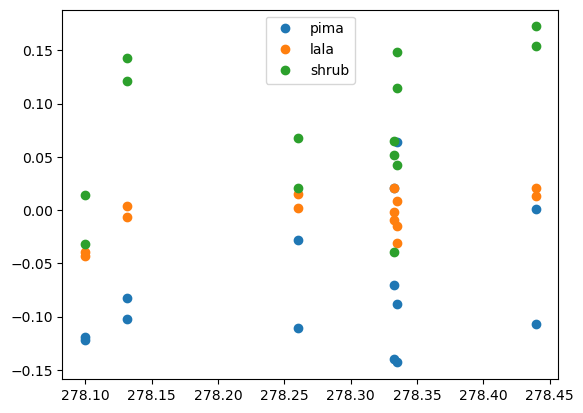

In [5]:
# Ad Spin-up
def get_ncfiles(prefix, year_range = range(104, 204)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h1.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

def get_ncfiles_col(prefix, year_range = range(104, 204)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h0.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

colfiles_good = get_ncfiles_col('20240317')
nc_files_good = get_ncfiles('20240317')
colfiles_bad = get_ncfiles_col('20240315_4')
nc_files_bad  = get_ncfiles('20240315_4')

ds = xr.open_mfdataset(nc_files_good)
ds2 = xr.open_mfdataset(nc_files_bad)
hr = xr.open_mfdataset(colfiles_good)
hr2 = xr.open_mfdataset(colfiles_bad)

plt.plot(hr['TBOT'][:,0]*0.64 + hr['TBOT'][:,1]*0.36,
         ds['TLAI'][:, 2]*0.64 + ds['TLAI'][:, 2+17]*0.36 - 
         ds['TLAI'][:,[2,2+17]].mean().mean(),
         'o', label = 'pima')
plt.plot(hr['TBOT'][:,0]*0.64 + hr['TBOT'][:,1]*0.36,
         ds['TLAI'][:, 3]*0.64 + ds['TLAI'][:, 3+17]*0.36 - 
         ds['TLAI'][:,[3,3+17]].mean().mean(), 'o', label = 'lala')
plt.plot(hr['TBOT'][:,0]*0.64 + hr['TBOT'][:,1]*0.36,
         ds['TLAI'][:, 11]*0.64 + ds['TLAI'][:, 11+17]*0.36 - 
         ds['TLAI'][:,[11,11+17]].mean().mean(), 'o', label = 'shrub')
plt.legend()

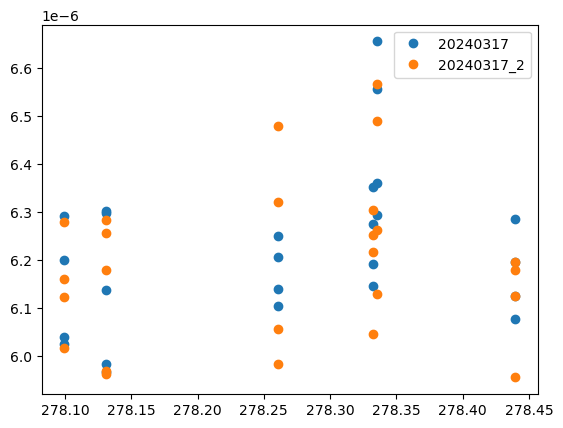

In [2]:
def get_ncfiles_col(prefix, year_range = range(50, 220)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h0.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

colfiles_good = get_ncfiles_col('20240317')
colfiles_bad = get_ncfiles_col('20240317_2')

hr = xr.open_mfdataset(colfiles_good)
hr2 = xr.open_mfdataset(colfiles_bad)

tair = hr['TBOT'].values[:,0]*0.64 + hr['TBOT'].values[:,1]*0.36
plt.plot(tair, hr['HR'].values[:, 0]*0.64 + hr['HR'].values[:, 1]*0.36, 'o', label = "20240317")
tair2 = hr2['TBOT'].values[:,0]*0.64 + hr2['TBOT'][:,1]*0.36
plt.plot(tair2 + 1e-6, hr2['HR'].values[:, 0]*0.64 + hr2['HR'][:, 1]*0.36, 'o', label = "20240317_2")
plt.legend()

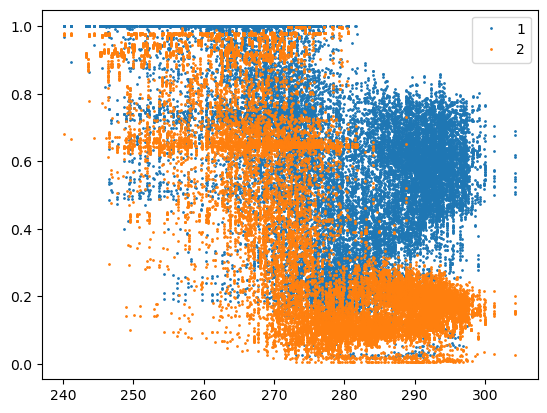

In [9]:
def get_ncfiles_col(prefix, year_range = range(1950, 2016)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB20TRCNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h0.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

colfiles_good = get_ncfiles_col('20231112')
colfiles_bad = get_ncfiles_col('20240317_4')

hr = xr.open_mfdataset(colfiles_good)
hr2 = xr.open_mfdataset(colfiles_bad)

tair = hr['TBOT'].values[:,0]*0.64 + hr['TBOT'].values[:,1]*0.36
plt.plot(tair, hr['FPI'].values[:, 0]*0.64 + hr['FPI'].values[:, 1]*0.36, 'o', label = "1", ms = 1)
tair2 = hr2['TBOT'].values[:,0]*0.64 + hr2['TBOT'][:,1]*0.36
plt.plot(tair2 + 1e-6, hr2['FPI'].values[:, 0]*0.64 + hr2['FPI'][:, 1]*0.36, 'o', label = "2", ms=1)
plt.legend()

In [ ]:
tair = hr['TBOT'].values[:,0]*0.64 + hr['TBOT'].values[:,1]*0.36
plt.plot(tair, hr['HR'].values[:, 0]*0.64 + hr['HR'].values[:, 1]*0.36, 'o', label = "1")
tair2 = hr2['TBOT'].values[:,0]*0.64 + hr2['TBOT'][:,1]*0.36
plt.plot(tair2 + 1e-6, hr2['HR'].values[:, 0]*0.64 + hr2['HR'][:, 1]*0.36, 'o', label = "2")
plt.legend()